# Full TRPO

We actually maintain most of the normal TRPO, but know we use the GAE as an estimator for the Advantage Function and compute the gradient using a natural gradient by approximating the Hessian.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, Iterable, List, Sequence, Tuple

import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
from torch import Tensor
from torch.distributions import Categorical
from torch.nn.utils import parameters_to_vector, vector_to_parameters

from pg_env import (
    ActionSample,
    BatchUpdateAgent,
    MLPPolicy,
    MLPValue,
    RolloutBatch,
    make_cartpole_env,
    to_tensor,
    train_on_policy_batches,
    plot_training_history,
    set_seed,
)

In [2]:
def get_flat_params(model: nn.Module) -> Tensor:
    """
    Return a detached flat parameter vector.
    """
    return parameters_to_vector(model.parameters()).detach().clone()


def set_flat_params(model: nn.Module, flat_params: Tensor) -> None:
    """
    Overwrite model parameters from a flat parameter vector.
    """
    vector_to_parameters(flat_params, model.parameters())


def get_flat_grad(
    loss: Tensor,
    model: nn.Module,
    retain_graph: bool = False,
    create_graph: bool = False,
) -> Tensor:
    """
    Flattened gradient of `loss` with respect to all parameters in `model`.
    """
    grads = torch.autograd.grad(
        loss,
        list(model.parameters()),
        retain_graph=retain_graph,
        create_graph=create_graph,
        allow_unused=False,
    )
    return torch.cat([g.reshape(-1) for g in grads])


def normalize_tensor(x: Tensor, eps: float = 1e-8) -> Tensor:
    """
    Normalize a 1D tensor to zero mean and unit std.
    """
    if x.numel() <= 1:
        return x
    return (x - x.mean()) / (x.std() + eps)

In [3]:
def compute_gae_and_returns(
    rewards: Tensor,
    values: Tensor,
    dones: Tensor,
    gamma: float,
    gae_lambda: float,
) -> Tuple[Tensor, Tensor]:
    """
    Compute Generalized Advantage Estimation (GAE-Lambda) for a flattened
    on-policy rollout batch.

    Args:
        rewards: [T]
        values: [T]
        dones: [T] boolean tensor marking episode ends
        gamma: discount factor
        gae_lambda: GAE lambda

    Returns:
        advantages: [T]
        returns: [T] where returns = advantages + values
    """
    T = rewards.shape[0]
    advantages = torch.zeros_like(rewards)

    last_gae = 0.0

    for t in reversed(range(T)):
        if t == T - 1 or dones[t]:
            next_value = 0.0
            next_nonterminal = 0.0
        else:
            next_value = values[t + 1]
            next_nonterminal = 1.0

        delta = rewards[t] + gamma * next_value * next_nonterminal - values[t]
        last_gae = delta + gamma * gae_lambda * next_nonterminal * last_gae
        advantages[t] = last_gae

    returns = advantages + values
    return advantages, returns

In [4]:
def conjugate_gradient(
    Avp_fn,
    b: Tensor,
    max_iters: int = 10,
    residual_tol: float = 1e-10,
) -> Tensor:
    """
    Approximately solve A x = b using conjugate gradient, where Avp_fn(v)
    returns A @ v without explicitly forming A.
    """
    x = torch.zeros_like(b)
    r = b.clone()
    p = r.clone()
    rdotr = torch.dot(r, r)

    for _ in range(max_iters):
        Avp = Avp_fn(p)
        alpha = rdotr / (torch.dot(p, Avp) + 1e-8)
        x = x + alpha * p
        r = r - alpha * Avp
        new_rdotr = torch.dot(r, r)

        if new_rdotr < residual_tol:
            break

        beta = new_rdotr / (rdotr + 1e-8)
        p = r + beta * p
        rdotr = new_rdotr

    return x

In [5]:
class FullTRPOAgent(BatchUpdateAgent):
    """
    Full TRPO agent for discrete action spaces.

    This implementation includes:
    - policy network
    - value network
    - GAE
    - differentiable KL
    - Fisher/Hessian-vector product
    - conjugate gradient
    - KL-based natural-gradient step
    - backtracking line search
    """

    def __init__(
        self,
        obs_dim: int,
        act_dim: int,
        hidden_sizes: Sequence[int] = (64, 64),
        gamma: float = 0.99,
        gae_lambda: float = 0.97,
        target_kl: float = 0.01,
        cg_iters: int = 10,
        backtrack_iters: int = 10,
        backtrack_coeff: float = 0.8,
        damping_coeff: float = 0.1,
        value_lr: float = 1e-3,
        value_train_iters: int = 80,
        device: torch.device | None = None,
    ) -> None:
        self.device = device or torch.device("cpu")

        self.gamma = gamma
        self.gae_lambda = gae_lambda
        self.target_kl = target_kl
        self.cg_iters = cg_iters
        self.backtrack_iters = backtrack_iters
        self.backtrack_coeff = backtrack_coeff
        self.damping_coeff = damping_coeff
        self.value_train_iters = value_train_iters

        self.policy = MLPPolicy(
            obs_dim=obs_dim,
            act_dim=act_dim,
            hidden_sizes=hidden_sizes,
        ).to(self.device)

        self.value_net = MLPValue(
            obs_dim=obs_dim,
            hidden_sizes=hidden_sizes,
        ).to(self.device)

        self.value_optimizer = torch.optim.Adam(
            self.value_net.parameters(),
            lr=value_lr,
        )

    # ------------------------------------------------------------------
    # Rollout interface
    # ------------------------------------------------------------------
    def _dist(self, obs_tensor: Tensor) -> Categorical:
        logits = self.policy(obs_tensor)
        return Categorical(logits=logits)

    def sample_action(self, obs: np.ndarray) -> ActionSample:
        obs_tensor = to_tensor(obs, self.device)

        with torch.no_grad():
            dist = self._dist(obs_tensor)
            action = dist.sample()
            log_prob = dist.log_prob(action)
            value = self.value_net(obs_tensor)

        return ActionSample(
            action=int(action.item()),
            log_prob=log_prob.detach().view(1),
            value=value.detach().view(1),
        )

    def predict_action(self, obs: np.ndarray) -> int:
        with torch.no_grad():
            obs_tensor = to_tensor(obs, self.device)
            logits = self.policy(obs_tensor)
            return int(torch.argmax(logits, dim=-1).item())

    # ------------------------------------------------------------------
    # Core policy math
    # ------------------------------------------------------------------
    def _policy_terms(
        self,
        obs: Tensor,
        actions: Tensor,
    ) -> Tuple[Categorical, Tensor, Tensor]:
        """
        Returns:
            dist: Categorical distribution under current policy
            log_probs: log pi(a|s) for provided actions
            entropy: per-sample entropy
        """
        dist = self._dist(obs)
        log_probs = dist.log_prob(actions)
        entropy = dist.entropy()
        return dist, log_probs, entropy

    def _surrogate_objective(
        self,
        obs: Tensor,
        actions: Tensor,
        old_log_probs: Tensor,
        advantages: Tensor,
    ) -> Tensor:
        """
        TRPO surrogate:
            E[ (pi_new / pi_old) * A ]
        """
        _, new_log_probs, _ = self._policy_terms(obs, actions)
        ratio = torch.exp(new_log_probs - old_log_probs)
        return torch.mean(ratio * advantages)

    def _mean_kl_from_old_dist(
        self,
        obs: Tensor,
        old_dist: Categorical,
    ) -> Tensor:
        """
        Mean KL(old || new), differentiable with respect to current policy params.
        """
        new_dist = self._dist(obs)
        kl = torch.distributions.kl.kl_divergence(old_dist, new_dist)
        return torch.mean(kl)

    def _hessian_vector_product(
        self,
        obs: Tensor,
        old_dist: Categorical,
        vector: Tensor,
    ) -> Tensor:
        """
        Compute Hessian-vector product for the KL Hessian:
            H v
        where H = ∇² KL(old || new) evaluated at current params.

        Uses Pearlmutter-style autograd trick.
        """
        mean_kl = self._mean_kl_from_old_dist(obs, old_dist)

        kl_grad = get_flat_grad(
            mean_kl,
            self.policy,
            retain_graph=True,
            create_graph=True,
        )

        grad_vector_product = torch.dot(kl_grad, vector)

        hvp = get_flat_grad(
            grad_vector_product,
            self.policy,
            retain_graph=False,
            create_graph=False,
        )

        return hvp + self.damping_coeff * vector

    # ------------------------------------------------------------------
    # Value fitting
    # ------------------------------------------------------------------
    def _fit_value_function(
        self,
        obs: Tensor,
        returns: Tensor,
    ) -> float:
        """
        Fit V(s) to returns with simple MSE regression.
        """
        last_loss = 0.0

        for _ in range(self.value_train_iters):
            values_pred = self.value_net(obs)
            value_loss = torch.mean((values_pred - returns) ** 2)

            self.value_optimizer.zero_grad()
            value_loss.backward()
            self.value_optimizer.step()

            last_loss = float(value_loss.item())

        return last_loss

    # ------------------------------------------------------------------
    # Main update
    # ------------------------------------------------------------------
    def update_from_batch(self, batch: RolloutBatch) -> Dict[str, float]:
        # --------------------------------------------------------------
        # 1) Tensorize rollout batch
        # --------------------------------------------------------------
        obs = torch.as_tensor(
            np.asarray(batch.observations),
            dtype=torch.float32,
            device=self.device,
        )
        actions = torch.as_tensor(batch.actions, dtype=torch.int64, device=self.device)
        rewards = torch.as_tensor(batch.rewards, dtype=torch.float32, device=self.device)
        dones = torch.as_tensor(batch.dones, dtype=torch.bool, device=self.device)

        # Stored rollout log_probs come from the old policy used for sampling.
        old_log_probs = torch.cat(
            [lp.view(1) for lp in batch.log_probs if lp is not None]
        ).to(self.device)

        # --------------------------------------------------------------
        # 2) Compute old values and GAE
        # --------------------------------------------------------------
        with torch.no_grad():
            old_values = self.value_net(obs)

        advantages, returns = compute_gae_and_returns(
            rewards=rewards,
            values=old_values,
            dones=dones,
            gamma=self.gamma,
            gae_lambda=self.gae_lambda,
        )
        advantages = normalize_tensor(advantages)

        # --------------------------------------------------------------
        # 3) Snapshot old policy distribution
        # --------------------------------------------------------------
        with torch.no_grad():
            old_logits = self.policy(obs)
            old_dist = Categorical(logits=old_logits)
            old_log_probs_check = old_dist.log_prob(actions)

            # Use stored rollout log-probs when available and shape-compatible.
            if old_log_probs.shape != old_log_probs_check.shape:
                old_log_probs = old_log_probs_check

        # --------------------------------------------------------------
        # 4) Compute surrogate gradient g
        # --------------------------------------------------------------
        surrogate = self._surrogate_objective(
            obs=obs,
            actions=actions,
            old_log_probs=old_log_probs,
            advantages=advantages,
        )

        policy_grad = get_flat_grad(
            surrogate,
            self.policy,
            retain_graph=True,
            create_graph=False,
        ).detach()

        # --------------------------------------------------------------
        # 5) Compute natural-gradient step direction via conjugate gradient
        # --------------------------------------------------------------
        def Avp_fn(v: Tensor) -> Tensor:
            return self._hessian_vector_product(obs, old_dist, v)

        step_dir = conjugate_gradient(
            Avp_fn=Avp_fn,
            b=policy_grad,
            max_iters=self.cg_iters,
        )

        # --------------------------------------------------------------
        # 6) Scale step to satisfy KL constraint
        # --------------------------------------------------------------
        shs = 0.5 * torch.dot(step_dir, Avp_fn(step_dir))
        step_scale = torch.sqrt(self.target_kl / (shs + 1e-8))
        full_step = step_dir * step_scale

        old_params = get_flat_params(self.policy)

        # --------------------------------------------------------------
        # 7) Backtracking line search
        # --------------------------------------------------------------
        accepted = False
        accepted_frac = 0.0
        surrogate_before = float(surrogate.item())

        approx_kl_value = 0.0
        entropy_value = 0.0

        for i in range(self.backtrack_iters):
            frac = self.backtrack_coeff ** i
            candidate_params = old_params + frac * full_step
            set_flat_params(self.policy, candidate_params)

            with torch.no_grad():
                surrogate_after = self._surrogate_objective(
                    obs=obs,
                    actions=actions,
                    old_log_probs=old_log_probs,
                    advantages=advantages,
                )
                kl_after = self._mean_kl_from_old_dist(obs, old_dist)
                _, _, entropy_after = self._policy_terms(obs, actions)

            improves_surrogate = surrogate_after.item() > surrogate_before
            respects_kl = kl_after.item() <= self.target_kl

            if improves_surrogate and respects_kl:
                accepted = True
                accepted_frac = frac
                approx_kl_value = float(kl_after.item())
                entropy_value = float(entropy_after.mean().item())
                break

        if not accepted:
            set_flat_params(self.policy, old_params)

            with torch.no_grad():
                kl_same = self._mean_kl_from_old_dist(obs, old_dist)
                _, _, entropy_same = self._policy_terms(obs, actions)

            approx_kl_value = float(kl_same.item())
            entropy_value = float(entropy_same.mean().item())

        # --------------------------------------------------------------
        # 8) Fit value function
        # --------------------------------------------------------------
        value_loss = self._fit_value_function(obs, returns)

        # --------------------------------------------------------------
        # 9) Recompute metrics for logging
        # --------------------------------------------------------------
        with torch.no_grad():
            surrogate_final = self._surrogate_objective(
                obs=obs,
                actions=actions,
                old_log_probs=old_log_probs,
                advantages=advantages,
            )
            _, new_log_probs, _ = self._policy_terms(obs, actions)
            ratio = torch.exp(new_log_probs - old_log_probs)

        return {
            "policy_loss": float(-surrogate_final.item()),
            "value_loss": float(value_loss),
            "surrogate_before": float(surrogate_before),
            "surrogate_after": float(surrogate_final.item()),
            "approx_kl": float(approx_kl_value),
            "entropy": float(entropy_value),
            "mean_ratio": float(ratio.mean().item()),
            "grad_norm": float(policy_grad.norm().item()),
            "step_dir_norm": float(step_dir.norm().item()),
            "full_step_norm": float(full_step.norm().item()),
            "accepted_step": 1.0 if accepted else 0.0,
            "line_search_frac": float(accepted_frac),
            "batch_mean_return": float(batch.mean_episode_return),
        }

In [6]:
def build_full_trpo_agent_from_env(
    env_fn,
    hidden_sizes: Sequence[int] = (64, 64),
    gamma: float = 0.99,
    gae_lambda: float = 0.97,
    target_kl: float = 0.01,
    cg_iters: int = 10,
    backtrack_iters: int = 10,
    backtrack_coeff: float = 0.8,
    damping_coeff: float = 0.1,
    value_lr: float = 1e-3,
    value_train_iters: int = 80,
    device: torch.device | None = None,
) -> FullTRPOAgent:
    env = env_fn()

    assert isinstance(env.observation_space, gym.spaces.Box), "Expected Box observation space."
    assert isinstance(env.action_space, gym.spaces.Discrete), "Expected Discrete action space."

    obs_dim = int(np.prod(env.observation_space.shape))
    act_dim = int(env.action_space.n)

    env.close()

    return FullTRPOAgent(
        obs_dim=obs_dim,
        act_dim=act_dim,
        hidden_sizes=hidden_sizes,
        gamma=gamma,
        gae_lambda=gae_lambda,
        target_kl=target_kl,
        cg_iters=cg_iters,
        backtrack_iters=backtrack_iters,
        backtrack_coeff=backtrack_coeff,
        damping_coeff=damping_coeff,
        value_lr=value_lr,
        value_train_iters=value_train_iters,
        device=device,
    )

[iter    1] batch_mean_return=  22.17 | steps= 4101 | episodes=185 | eval_mean_return= 117.80 | policy_loss=  -0.0172
[iter    5] batch_mean_return=  70.03 | steps= 4132 | episodes= 59 | eval_mean_return= 500.00 | policy_loss=  -0.0226
[iter   10] batch_mean_return= 317.62 | steps= 4129 | episodes= 13 | eval_mean_return= 500.00 | policy_loss=  -0.0108
[iter   15] batch_mean_return= 500.00 | steps= 4500 | episodes=  9 | eval_mean_return= 500.00 | policy_loss=  -0.0096
[iter   20] batch_mean_return= 500.00 | steps= 4500 | episodes=  9 | eval_mean_return= 500.00 | policy_loss=  -0.0043
[iter   25] batch_mean_return= 500.00 | steps= 4500 | episodes=  9 | eval_mean_return= 500.00 | policy_loss=  -0.0016
[iter   30] batch_mean_return= 500.00 | steps= 4500 | episodes=  9 | eval_mean_return= 500.00 | policy_loss=  -0.0075
[iter   35] batch_mean_return= 500.00 | steps= 4500 | episodes=  9 | eval_mean_return= 500.00 | policy_loss=  -0.0034
[iter   40] batch_mean_return= 500.00 | steps= 4500 | ep

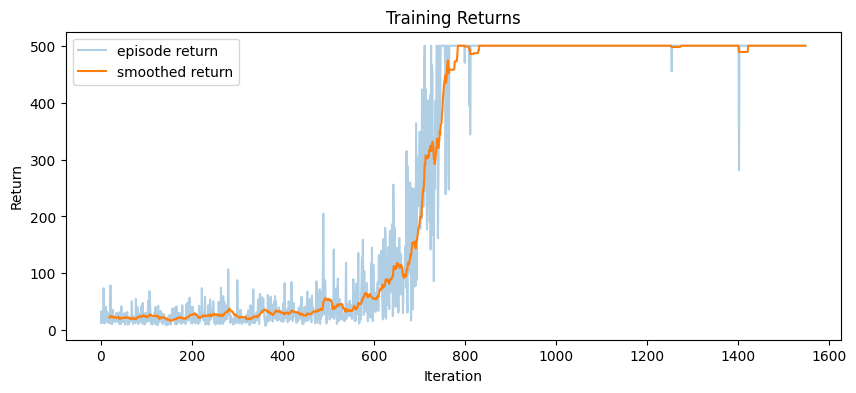

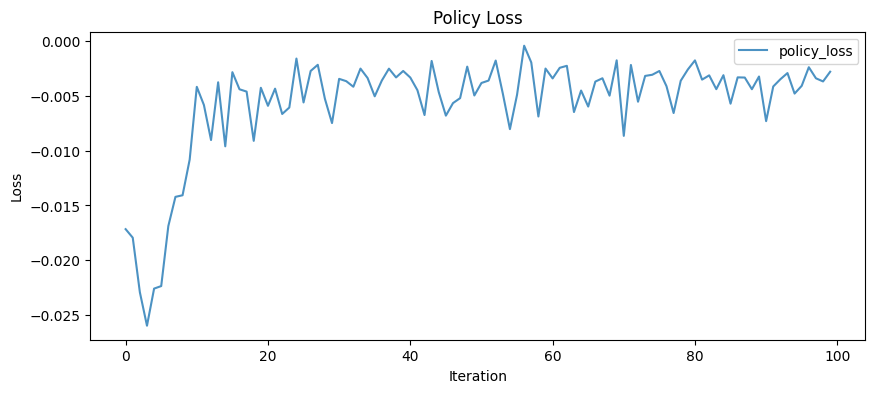

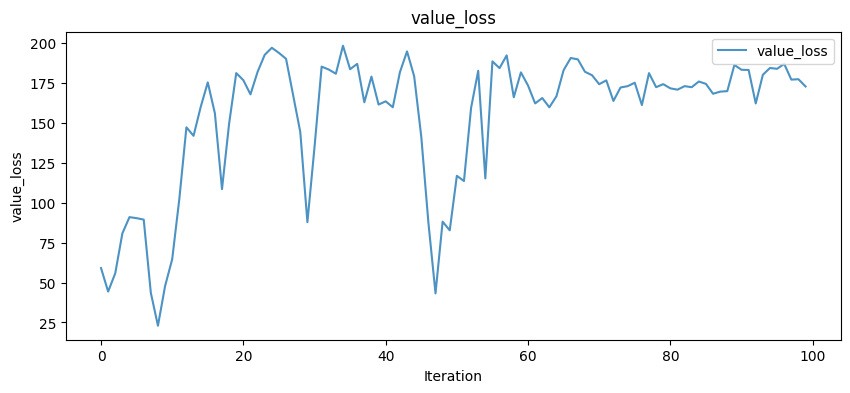

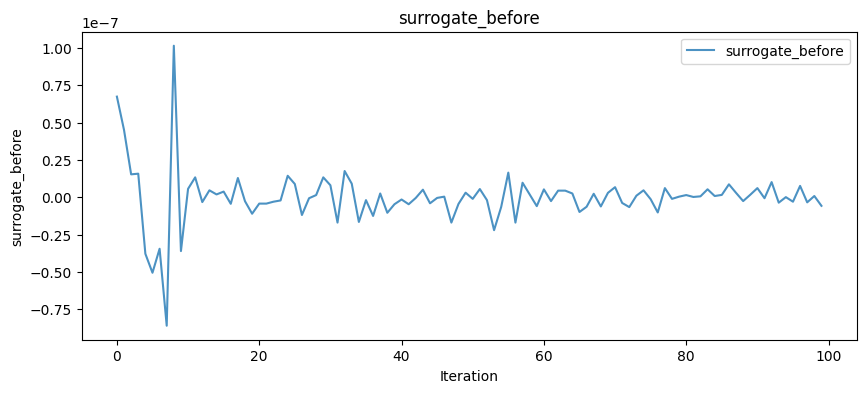

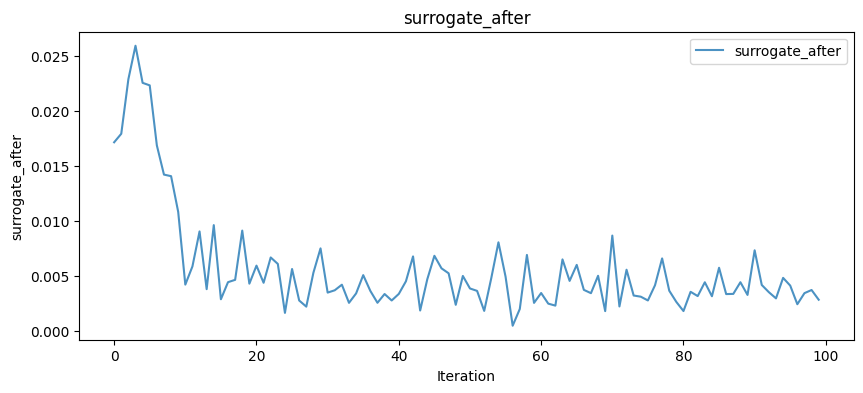

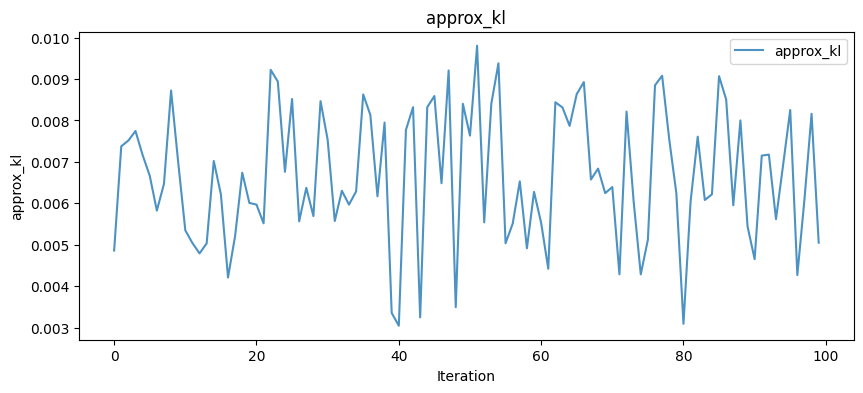

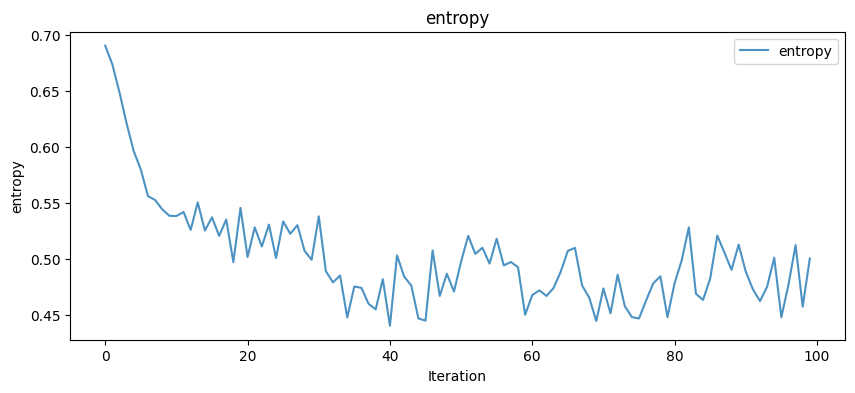

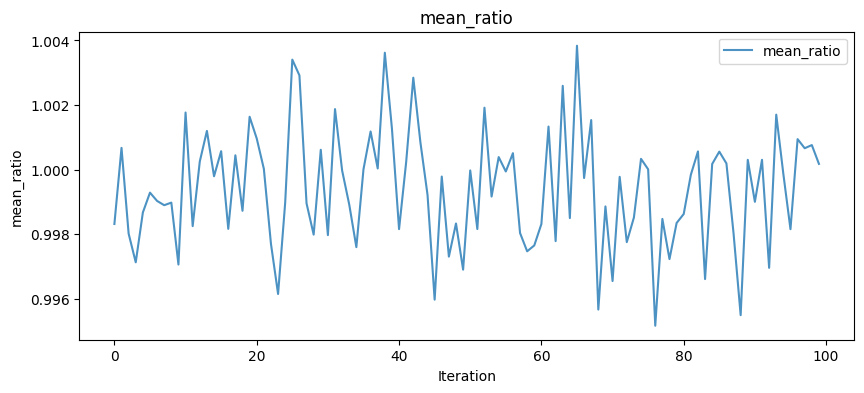

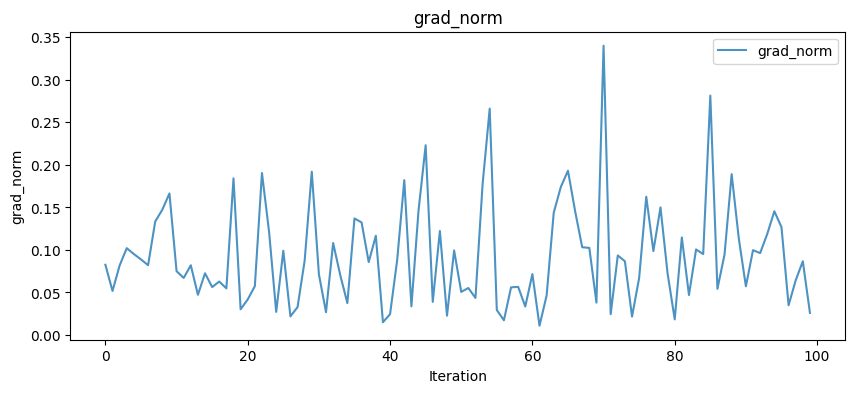

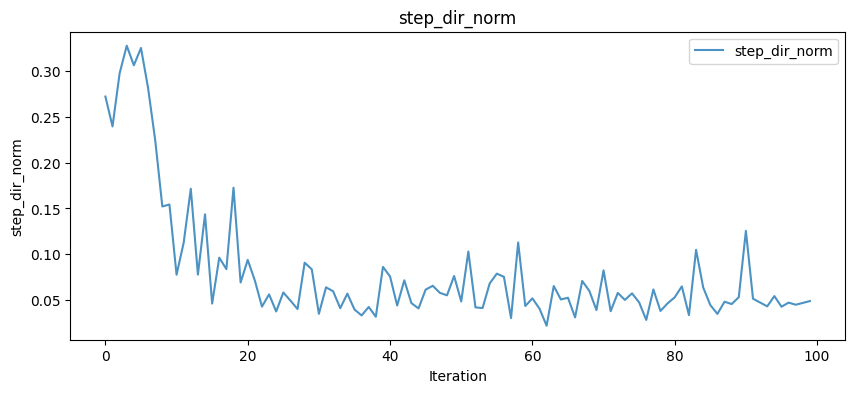

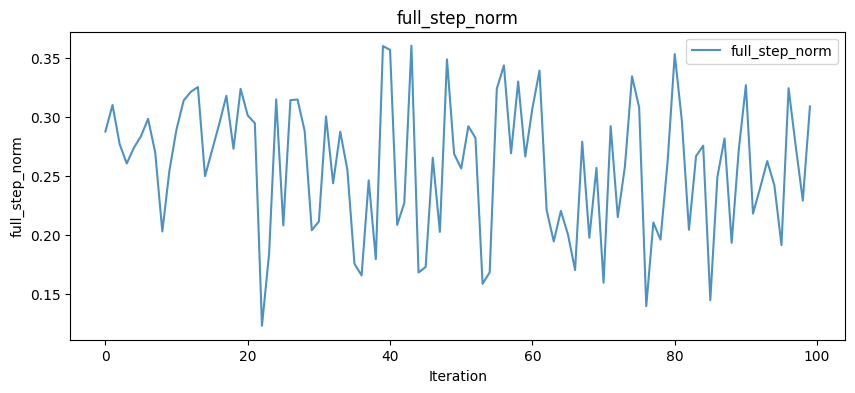

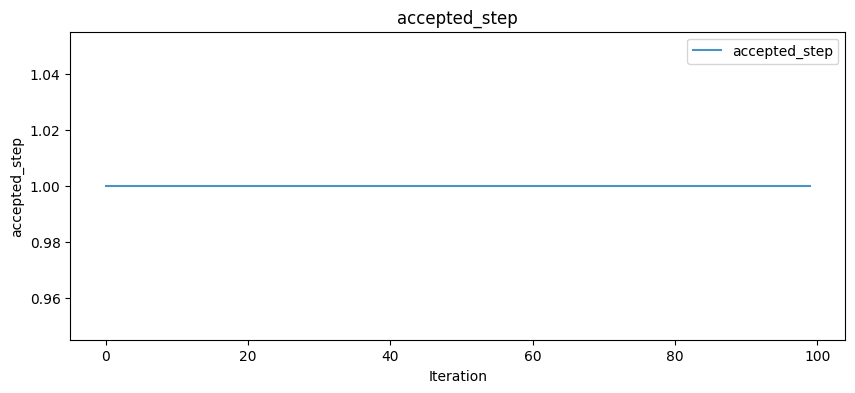

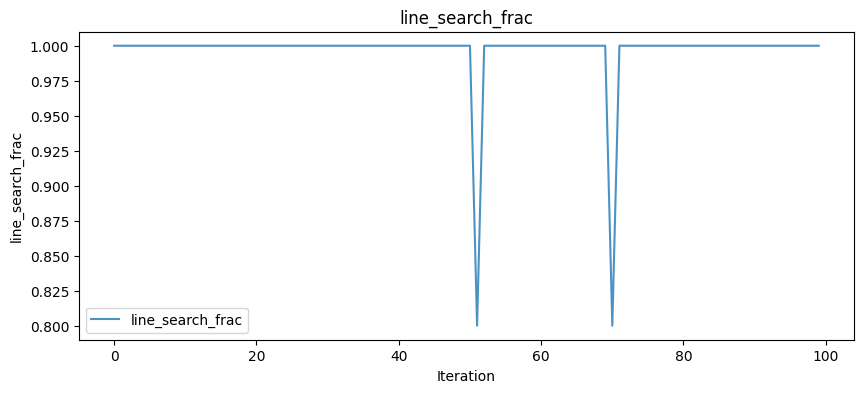

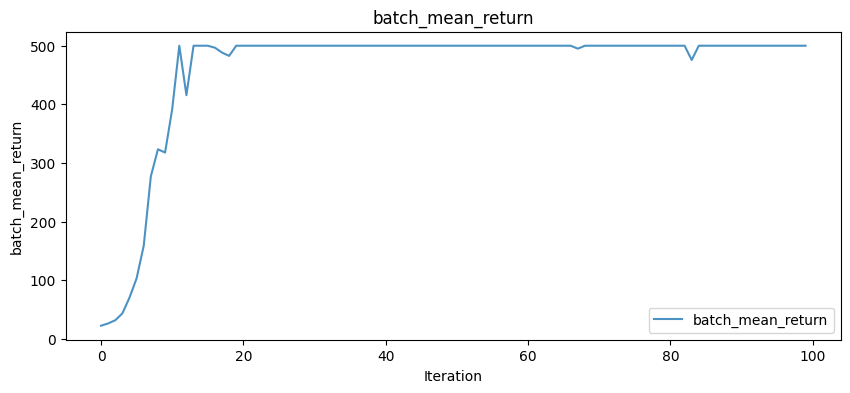

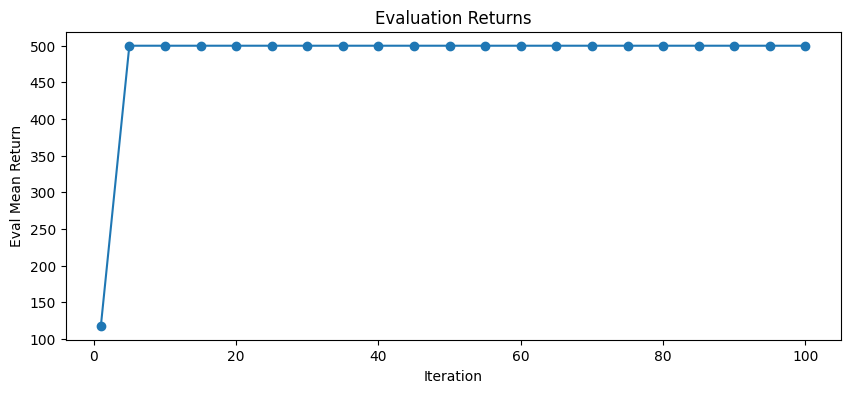

In [7]:
set_seed(42)

env_fn = lambda: make_cartpole_env(render_mode=None)

agent = build_full_trpo_agent_from_env(
    env_fn=env_fn,
    hidden_sizes=(64, 64),
    gamma=0.99,
    gae_lambda=0.97,
    target_kl=0.01,
    cg_iters=10,
    backtrack_iters=10,
    backtrack_coeff=0.8,
    damping_coeff=0.1,
    value_lr=1e-3,
    value_train_iters=80,
)


history = train_on_policy_batches(
    env_fn=env_fn,
    agent=agent,
    num_iterations=100,
    batch_size=4096,
    eval_every=5,
    eval_episodes=5,
    verbose=True,
)

plot_training_history(history)

In [9]:
from pg_env import run_demo_episode

In [10]:
visual_env = lambda: make_cartpole_env(render_mode="human")

run_demo_episode(visual_env, agent, greedy=True)


/mnt/hd/Repos/ds_be_like/.venv/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Demo return: 500.00


500.0